# 00 - Data Audit (Step 0)

Per-station, per-sensor coverage audit of the raw µEMA CSVs: time range, sampling
gaps, missing-value patterns, and an explicit go/no-go call for this analysis
phase. Every downstream method's results are meaningless without first knowing
which stations have enough clean data to evaluate on — this is done first, on
purpose, rather than discovered later after running a full method comparison.

Outputs (coverage table, station recommendation, timeline figure, and the
written rationale) are saved to `reports/data_audit/` for reuse by later steps.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

from uema.audit import (
    build_coverage_table,
    coverage_segments,
    station_availability,
    station_recommendation,
)
from uema.io import FEATURES, discover_raw_files
from uema.style import PALETTE, apply_style

apply_style()

REPORT_DIR = Path("..") / "reports" / "data_audit"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 80)

## Coverage table

One row per station × sensor: time range, expected vs. actual 10-minute bins,
%missing, gap count, and the largest single gap.

In [2]:
coverage = build_coverage_table()
coverage.to_csv(REPORT_DIR / "coverage_table.csv", index=False)
coverage

,station,feature,start,end,span_days,expected_rows,actual_rows,missing_rows,pct_missing,n_gaps,max_gap
0,recinto-esparza,luminous_intensity,2024-11-21 15:00:00,2026-03-01 00:00:00,464.375000,66871,62519,4352,6.508053,254,3 days 08:10:00
1,recinto-esparza,precipitation,2024-10-27 00:10:00,2026-03-01 00:00:00,489.993056,70560,70560,0,0.000000,0,0 days 00:00:00
2,recinto-esparza,pressure,2024-11-21 15:00:00,2026-03-01 00:00:00,464.375000,66871,62519,4352,6.508053,254,3 days 08:10:00
3,recinto-guapiles,luminous_intensity,2025-04-26 19:10:00,2026-03-01 00:00:00,308.201389,44382,21726,22656,51.047722,39,64 days 06:50:00
4,recinto-guapiles,precipitation,2025-04-25 00:10:00,2026-03-01 00:00:00,309.993056,44640,40320,4320,9.677419,1,30 days 00:10:00
5,recinto-guapiles,pressure,2025-11-19 10:50:00,2025-11-19 13:40:00,0.118056,18,18,0,0.000000,0,0 days 00:00:00
6,recinto-santa-cruz,luminous_intensity,2024-12-12 17:00:00,2026-03-01 00:00:00,443.291667,63835,33892,29943,46.906869,58,42 days 21:00:00
7,recinto-santa-cruz,precipitation,2024-11-26 00:10:00,2026-03-01 00:00:00,459.993056,66240,66240,0,0.000000,0,0 days 00:00:00
8,recinto-santa-cruz,pressure,2024-12-12 17:00:00,2026-03-01 00:00:00,443.291667,63835,33892,29943,46.906869,58,42 days 21:00:00
9,sede-atlantico_turrialba,luminous_intensity,2024-10-03 11:40:00,2026-03-01 00:00:00,513.513889,73947,71757,2190,2.961581,64,3 days 18:40:00


## Operational timeline

For every station, three rows (one per sensor) show actually-present data as
filled segments, with white gaps wherever bins are missing — not just each
sensor's overall start/end.

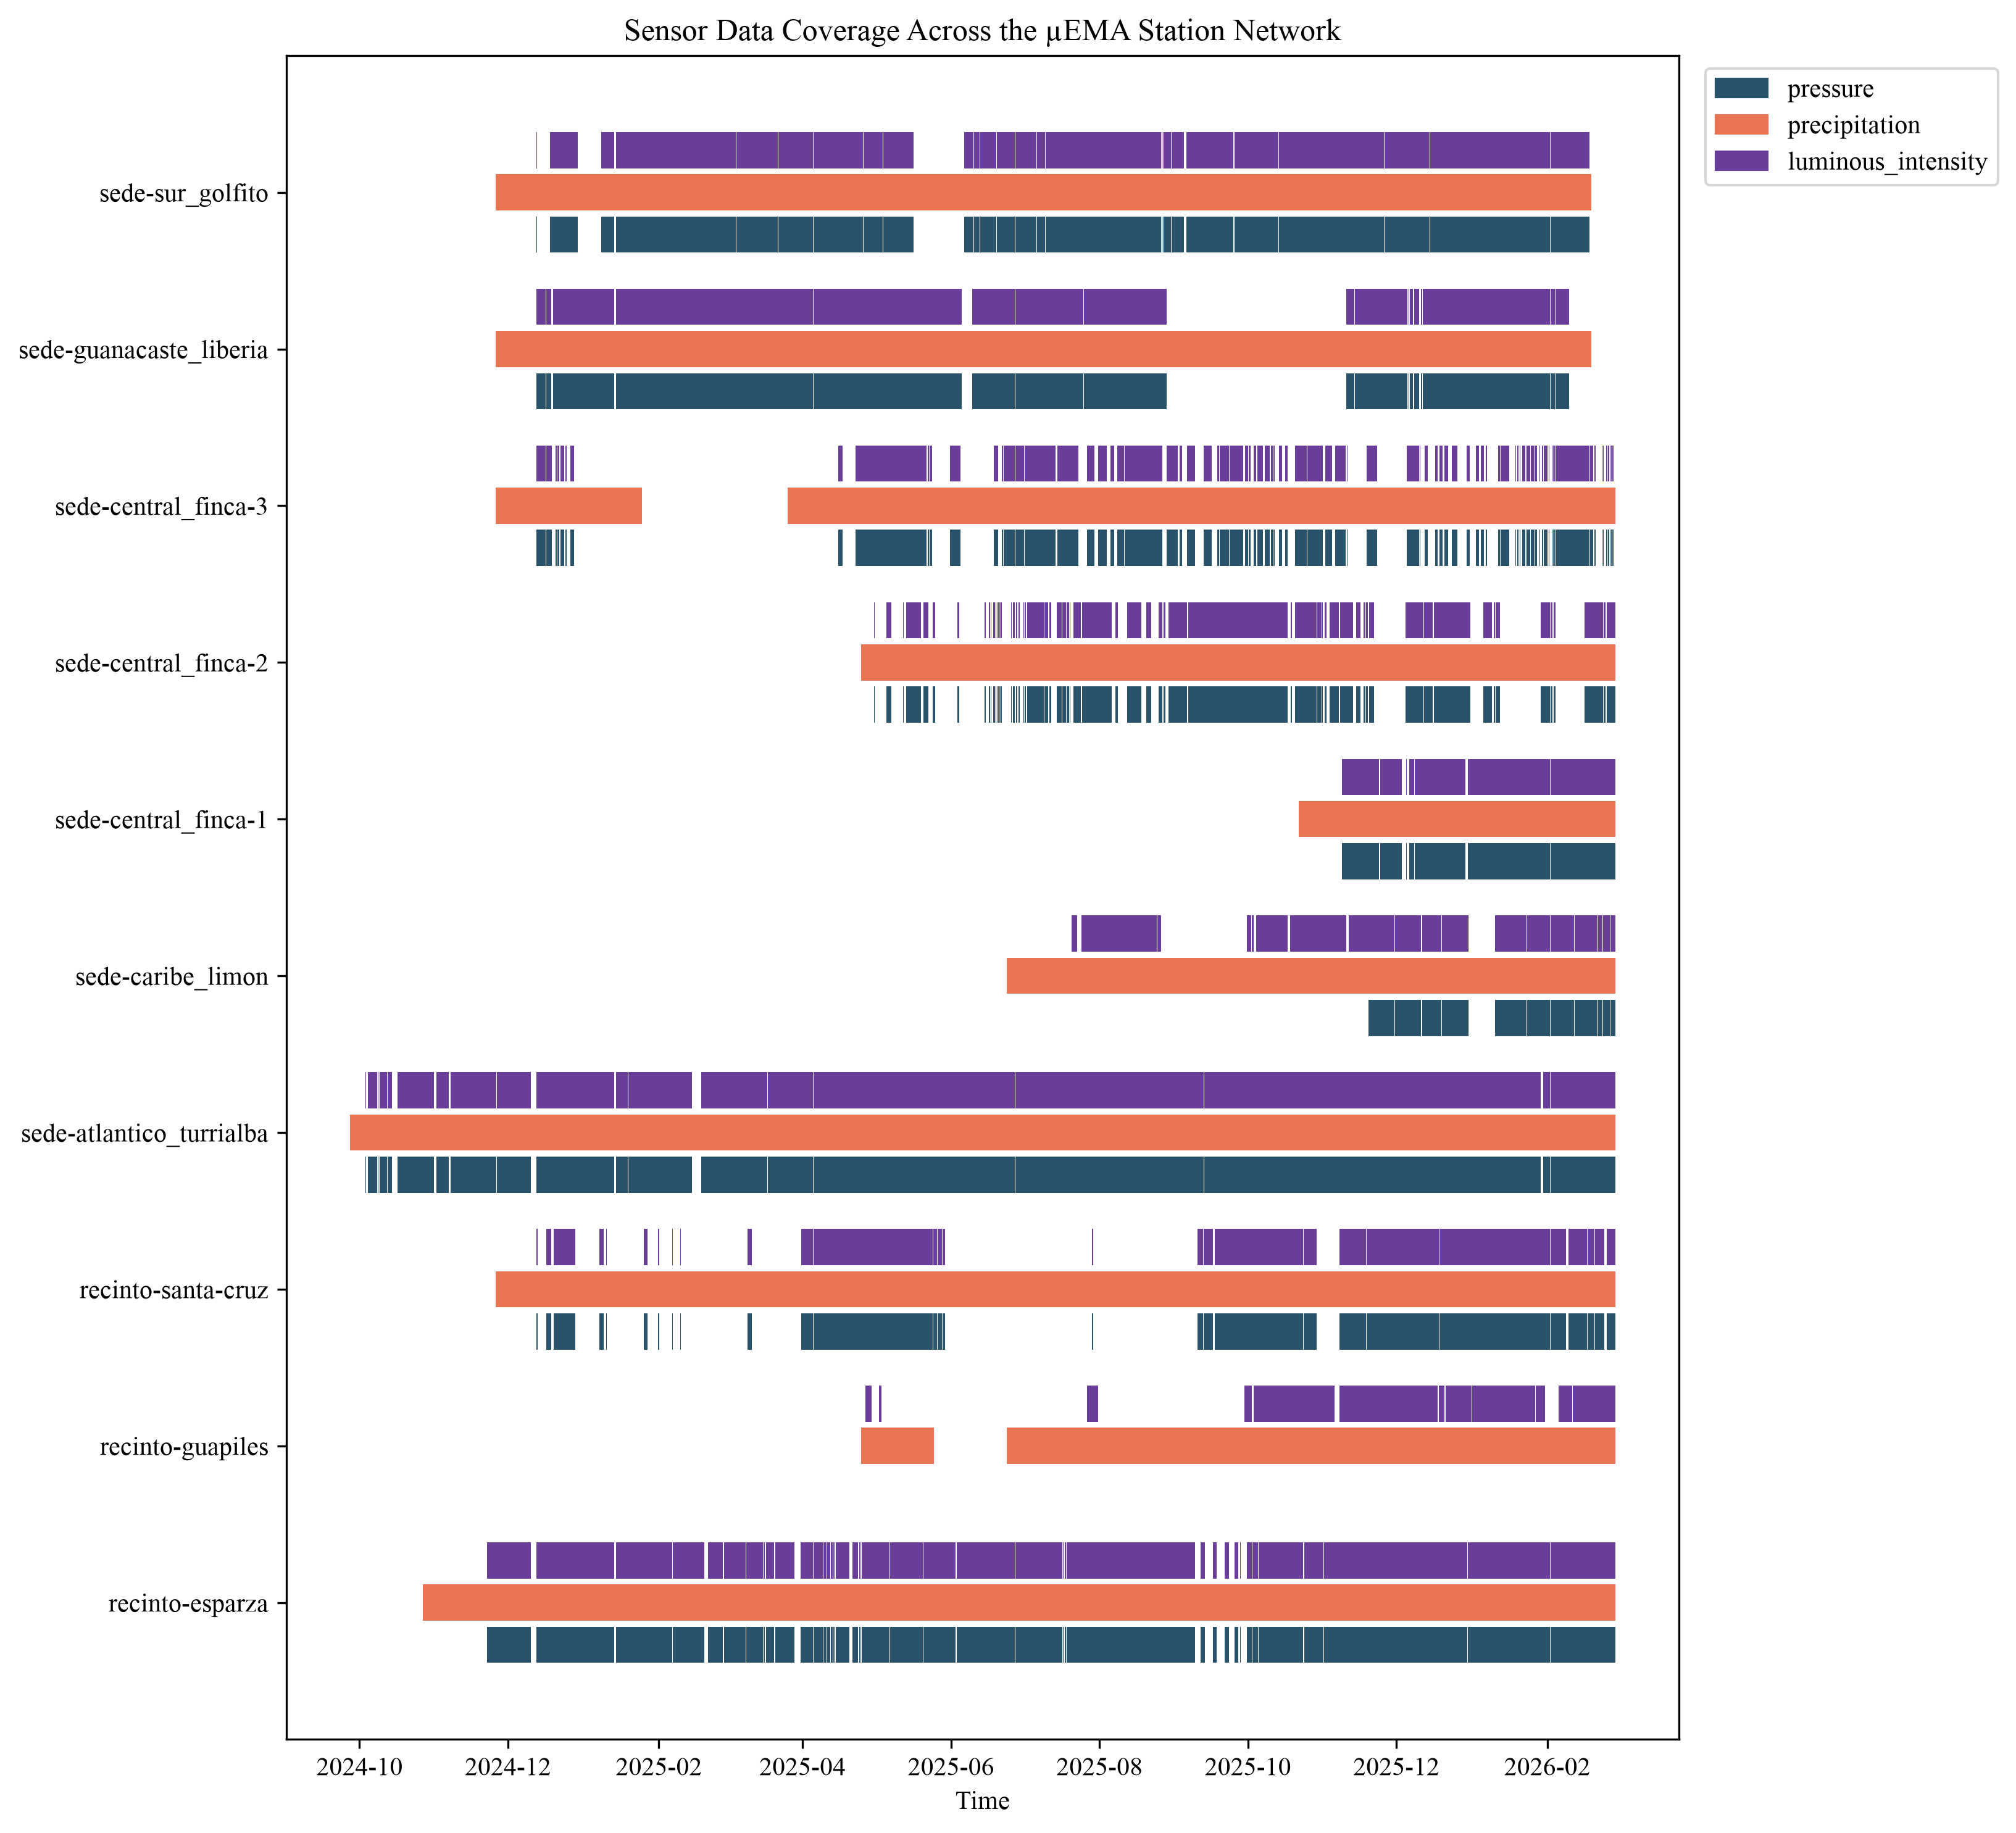

In [3]:
SENSOR_COLORS = {
    "pressure": PALETTE["indigo"],
    "precipitation": PALETTE["burnt_sienna"],
    "luminous_intensity": PALETTE["violet"],
}

raw_files = discover_raw_files()
stations = sorted({f.station for f in raw_files})

row_height = 0.6
sensor_offset = {"pressure": 0.0, "precipitation": 0.7, "luminous_intensity": 1.4}

fig, ax = plt.subplots(figsize=(11, 0.9 * len(stations) + 1))

for station_i, station in enumerate(stations):
    base_y = station_i * 2.6
    for f in [rf for rf in raw_files if rf.station == station]:
        segments = coverage_segments(f)
        bars = [
            (mdates.date2num(start), mdates.date2num(end) - mdates.date2num(start))
            for start, end in segments
        ]
        y = base_y + sensor_offset[f.feature]
        ax.broken_barh(bars, (y, row_height), facecolors=SENSOR_COLORS[f.feature])

ax.xaxis_date()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.set_yticks([i * 2.6 + 1.0 for i in range(len(stations))])
ax.set_yticklabels(stations)
ax.set_xlabel("Time")
ax.set_title("Sensor Data Coverage Across the µEMA Station Network")

handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in SENSOR_COLORS.values()]
ax.legend(handles, SENSOR_COLORS.keys(), loc="upper left", bbox_to_anchor=(1.01, 1.0))

fig.tight_layout()
fig.savefig(REPORT_DIR / "timeline.png")
plt.show()

## Per-station go/no-go

Explicit, documented decision for this analysis phase — see
`uema.audit.station_recommendation` for the thresholds (90-day minimum span,
\>25% missing = degraded, >=90% missing = effectively absent) and
`reports/data_audit/README.md` for the written rationale.

In [4]:
recommendation = station_recommendation(coverage)
recommendation.to_csv(REPORT_DIR / "station_recommendation.csv")
recommendation

,luminous_intensity,precipitation,pressure,decision,rationale
station,,,,,
recinto-esparza,ok,ok,ok,GO,all sensors within coverage thresholds
recinto-guapiles,degraded,ok,short-history,NO-GO,pressure sensor span under 90 days — insufficient history to use
recinto-santa-cruz,degraded,ok,degraded,CONDITIONAL-GO,"usable with caveats on: luminous_intensity, pressure"
sede-atlantico_turrialba,ok,ok,ok,GO,all sensors within coverage thresholds
sede-caribe_limon,ok,ok,ok,NO-GO,manual override: flagged by manual review despite clearing numeric thresholds
sede-central_finca-1,ok,ok,ok,GO,all sensors within coverage thresholds
sede-central_finca-2,degraded,ok,degraded,CONDITIONAL-GO,"usable with caveats on: luminous_intensity, pressure"
sede-central_finca-3,degraded,ok,degraded,CONDITIONAL-GO,"usable with caveats on: luminous_intensity, pressure"
sede-guanacaste_liberia,ok,ok,ok,GO,all sensors within coverage thresholds


In [5]:
recommendation["decision"].value_counts()

decision
GO                5
CONDITIONAL-GO    3
NO-GO             2
Name: count, dtype: int64

## Operational timeline, grouped by decision

Same per-sensor coverage segments as above, but split into two blocks — GO
stations, then CONDITIONAL-GO/NO-GO stations together — each block sorted by
overall data availability (highest first). Makes it easy to see at a glance
how much more/less data the excluded/caveated stations actually have versus
the clean ones.

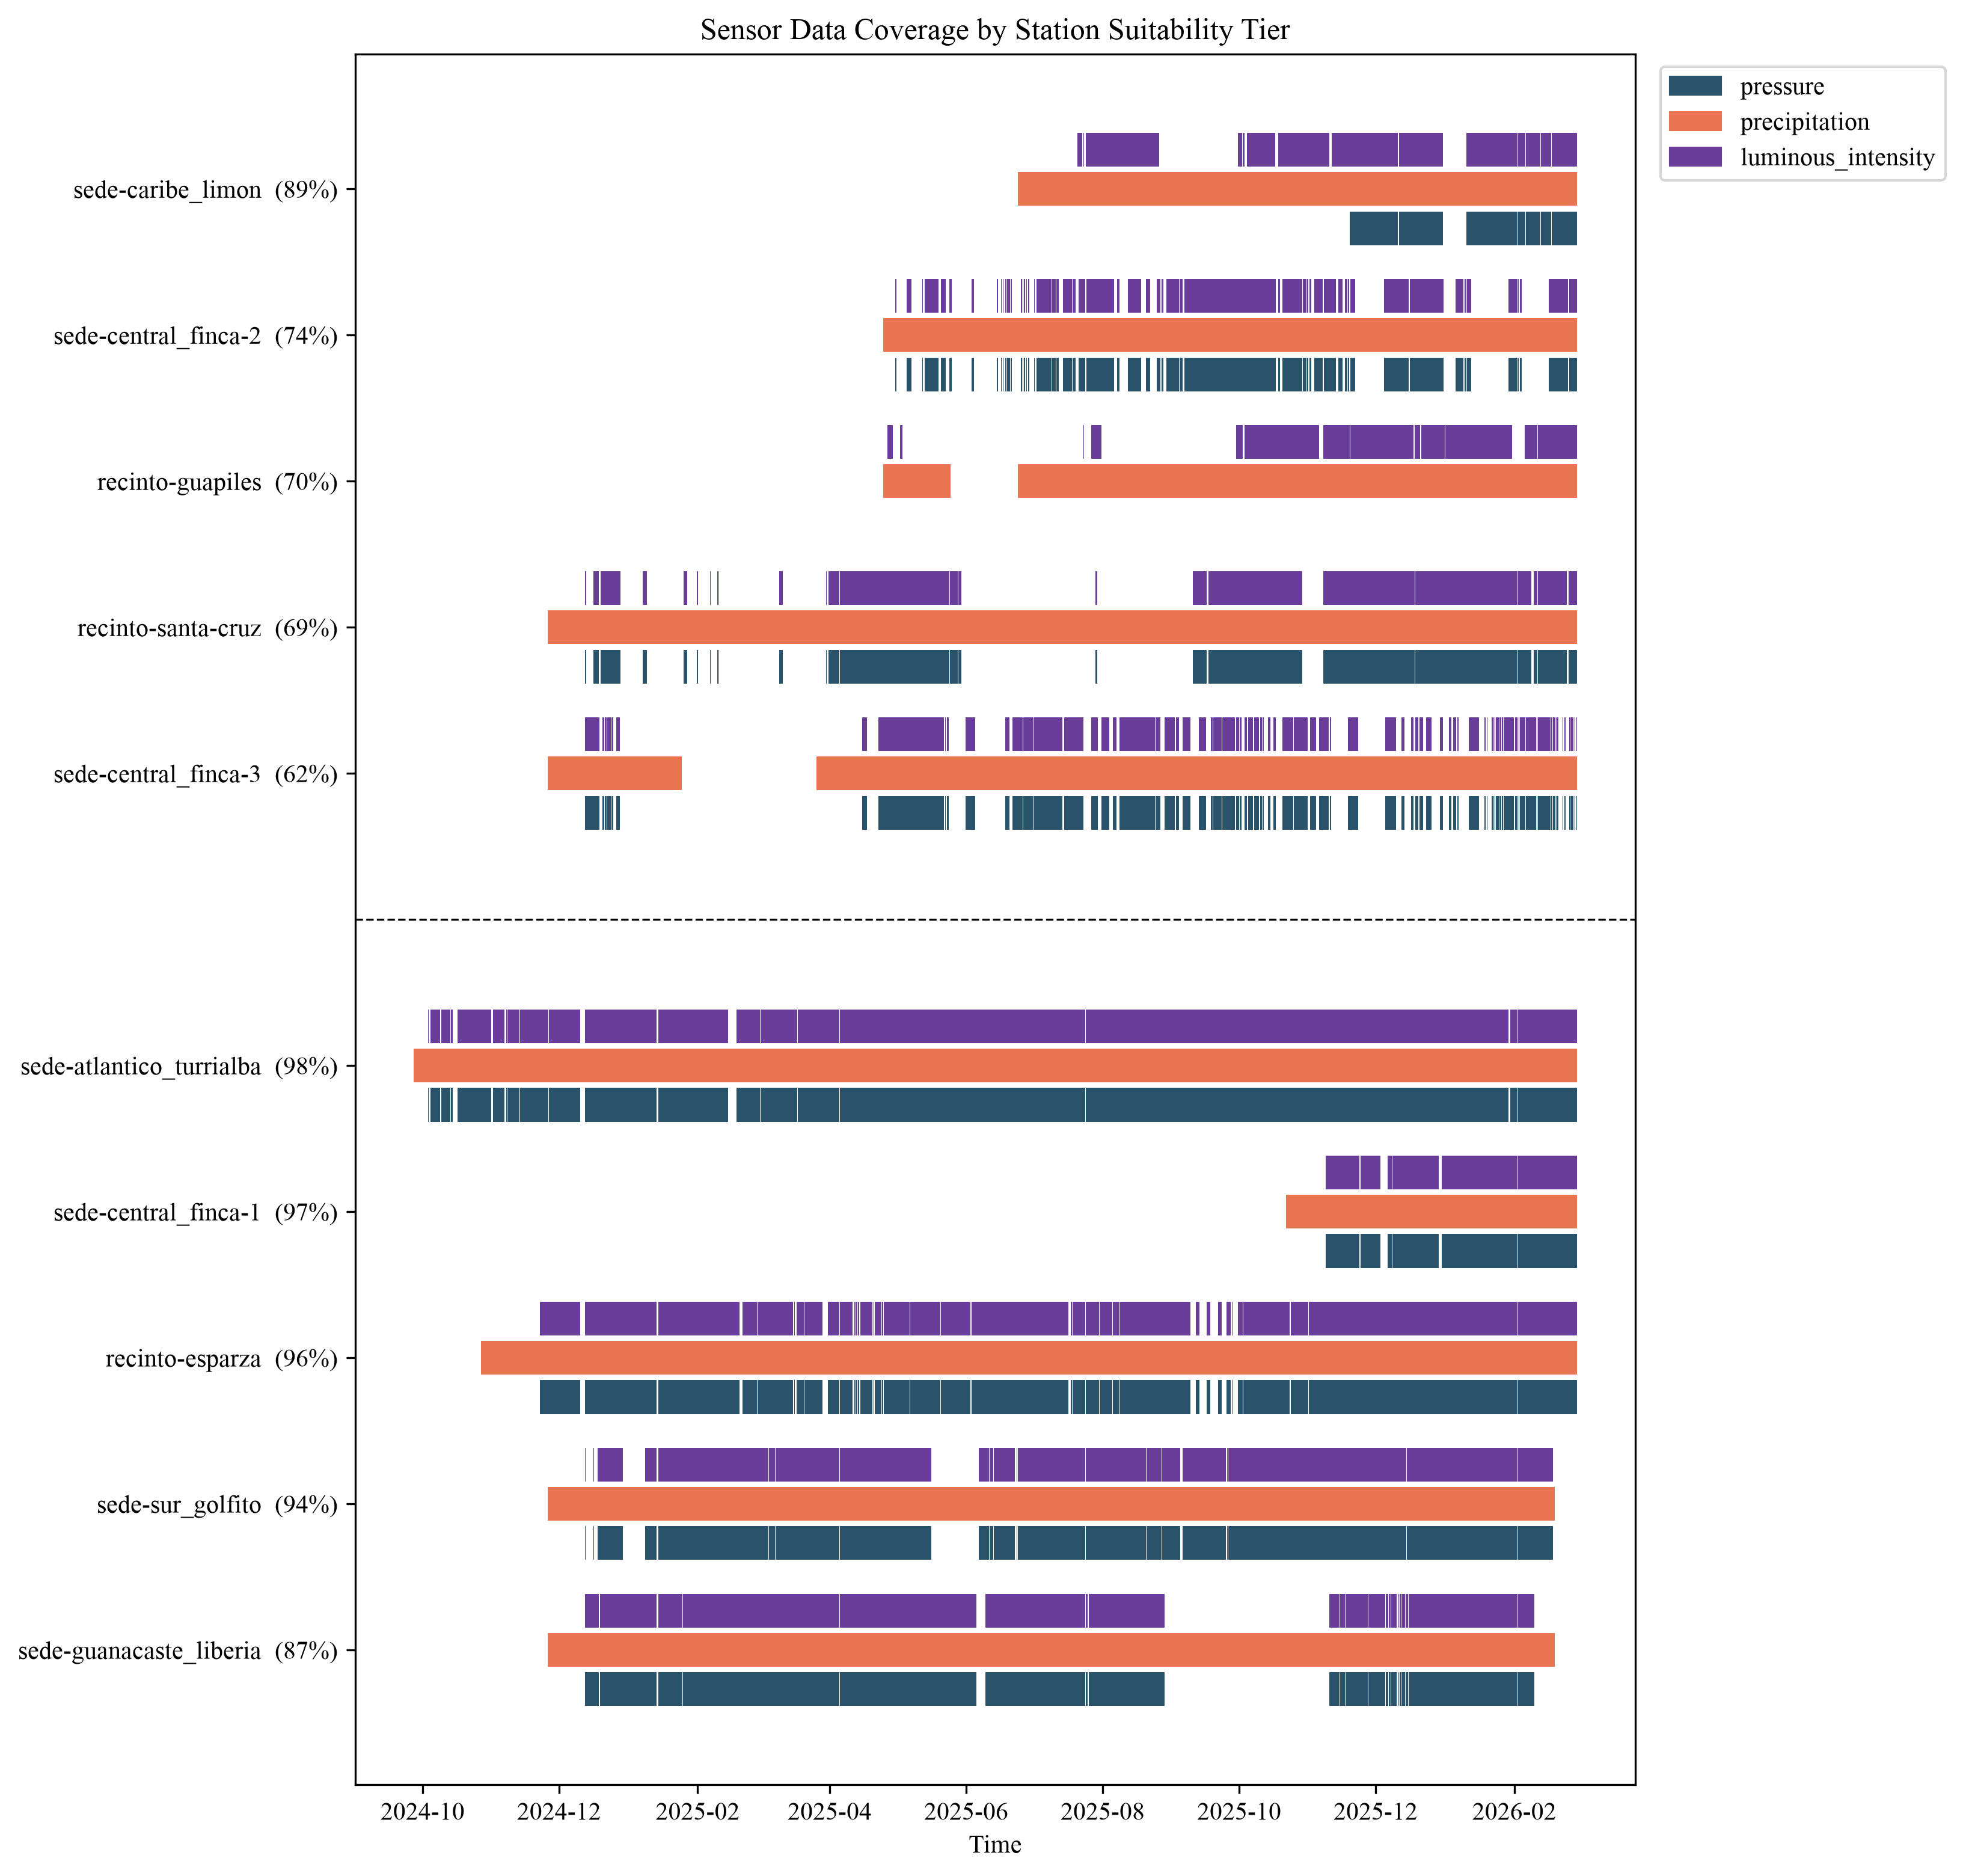

In [6]:
availability = station_availability(coverage)

go_stations = recommendation.index[recommendation["decision"] == "GO"]
other_stations = recommendation.index[recommendation["decision"] != "GO"]

# Ascending within each block: since rows are plotted bottom-to-top, the
# highest-availability station in a block ends up nearest its top.
go_sorted = availability.loc[go_stations].sort_values(ascending=True).index.tolist()
other_sorted = availability.loc[other_stations].sort_values(ascending=True).index.tolist()

row_height = 0.6
sensor_offset = {"pressure": 0.0, "precipitation": 0.7, "luminous_intensity": 1.4}
GROUP_GAP = 2.6

# GO block plotted first (bottom of figure), then a blank gap, then the
# CONDITIONAL-GO/NO-GO block (top of figure) — no placeholder row in the
# station list itself, so tick labels line up exactly with plotted stations.
y_by_station: dict[str, float] = {}
y = 0.0
for station in go_sorted:
    y_by_station[station] = y
    y += 2.6
divider_y = y + GROUP_GAP / 2 - row_height / 2
y += GROUP_GAP
for station in other_sorted:
    y_by_station[station] = y
    y += 2.6

ordered_stations = go_sorted + other_sorted

fig, ax = plt.subplots(figsize=(11, 0.9 * len(ordered_stations) + 1.5))

for station in ordered_stations:
    base_y = y_by_station[station]
    for f in [rf for rf in raw_files if rf.station == station]:
        segments = coverage_segments(f)
        bars = [
            (mdates.date2num(start), mdates.date2num(end) - mdates.date2num(start))
            for start, end in segments
        ]
        y_bar = base_y + sensor_offset[f.feature]
        ax.broken_barh(bars, (y_bar, row_height), facecolors=SENSOR_COLORS[f.feature])

ax.xaxis_date()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.set_yticks([y_by_station[s] + 1.0 for s in ordered_stations])
ax.set_yticklabels(
    [f"{s}  ({availability[s]:.0%})" for s in ordered_stations]
)
ax.axhline(divider_y, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Time")
ax.set_title("Sensor Data Coverage by Station Suitability Tier")

handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in SENSOR_COLORS.values()]
ax.legend(handles, SENSOR_COLORS.keys(), loc="upper left", bbox_to_anchor=(1.01, 1.0))

fig.tight_layout()
fig.savefig(REPORT_DIR / "timeline_grouped.png")
plt.show()